# Multi-Section Semantic Drift and Return Predictability
## Evidence from S&P 500 10-K Filings (2005–2024)

Uses the CRSP return panel from `pull_crsp_returns.ipynb` which ensures:
- Returns start **the month after** the 10-K filing date (no look-ahead)
- ~500 firms per month for proper Fama-MacBeth cross-sections
- CRSP market cap (not total assets) for size control
- Book-to-market from Compustat/CRSP for value control

| Table | Content |
|---|---|
| 1 | Descriptive statistics |
| 2 | Quintile portfolio sorts (all signals) |
| 3 | Fama-MacBeth regressions (per signal) |
| 4 | L/S alphas: FF3, Carhart, FF5, FF6 |
| 5 | Horse-race: all signals in one regression |

## 0. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


## 1. Configuration

In [2]:
import os

BASE = '/content/drive/MyDrive/FML_project_4'

CONFIG = {
    'signals': {
        'item_1':  os.path.join(BASE, 'semantic_drift_minilm_item1.parquet'),
        'item_1A': os.path.join(BASE, 'semantic_drift_minilm_item1a.parquet'),
        'item_7':  os.path.join(BASE, 'semantic_drift_minilm_item7.parquet'),
    },
    'returns_path':  os.path.join(BASE, 'crsp_returns_panel.parquet'),
    'output_folder': BASE,
    'nw_lags':   6,
    'winsor':    0.01,
    'min_xsec':  30,
    'start_year': 2005,
    'end_year':   2024,
}

SIGNAL_LABELS = {
    'item_1':    'Item 1 (Business)',
    'item_1A':   'Item 1A (Risk)',
    'item_7':    'Item 7 (MD&A)',
    'composite': 'Composite',
}
print('Config OK')

Config OK


## 2. Dependencies

In [3]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'pyarrow', 'pandas-datareader',
                'statsmodels', 'tqdm'], check=True)

import warnings, numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})
print('OK')

OK


## 3. Load data

In [4]:
# ── Load return panel (already forward-aligned from CRSP pull) ────
panel = pd.read_parquet(CONFIG['returns_path'])
panel['cik']          = panel['cik'].astype(str).str.strip().str.lstrip('0')
panel['year']         = panel['year'].astype('Int64')
panel['filing_date']  = pd.to_datetime(panel['filing_date'])
panel['return_month'] = pd.to_datetime(panel['return_month'])
print(f'Return panel: {len(panel):,} rows  |  {panel["cik"].nunique():,} CIKs  |  '
      f'{panel["return_month"].nunique():,} months')

# ── Load and merge drift signals ──────────────────────────────────
def load_drift(path, key):
    df = pd.read_parquet(path)
    df['cik']  = df['cik'].astype(str).str.strip().str.lstrip('0')
    df['year'] = df['year'].astype('Int64')
    df = df[
        (df['year'].astype(int) - df['year_prev'].astype(int) == 1)
    ].dropna(subset=['semantic_drift'])
    df = df[df['year'].between(CONFIG['start_year'], CONFIG['end_year'])]
    print(f'  {key}: {len(df):,} obs')
    return df[['cik', 'year', 'semantic_drift']].rename(
        columns={'semantic_drift': f'drift_{key}'}
    )

print('Loading drift signals:')
drift_dfs = {k: load_drift(v, k) for k, v in CONFIG['signals'].items()}

# Merge all signals
drift_all = drift_dfs[list(drift_dfs.keys())[0]]
for k in list(drift_dfs.keys())[1:]:
    drift_all = drift_all.merge(drift_dfs[k], on=['cik', 'year'], how='outer')

# Composite = mean of per-section drift scores
section_cols = [f'drift_{k}' for k in CONFIG['signals'].keys()]
drift_all['drift_composite'] = drift_all[section_cols].mean(axis=1)
all_drift_cols = section_cols + ['drift_composite']

# Merge signals into panel
panel = panel.merge(drift_all, on=['cik', 'year'], how='inner')
panel = panel.dropna(subset=all_drift_cols, how='all')

print(f'\nPanel after signal merge: {len(panel):,} rows  |  '
      f'{panel["cik"].nunique():,} CIKs  |  '
      f'{panel["return_month"].nunique():,} months')

# Sanity: firms per month
mc = panel.groupby('return_month')['cik'].nunique()
print(f'Firms per month: mean={mc.mean():.0f}, median={mc.median():.0f}, '
      f'min={mc.min()}, months≥30: {(mc>=30).sum()}')

Return panel: 119,252 rows  |  839 CIKs  |  252 months
Loading drift signals:
  item_1: 13,742 obs
  item_1A: 12,247 obs
  item_7: 13,801 obs

Panel after signal merge: 112,240 rows  |  811 CIKs  |  240 months
Firms per month: mean=435, median=444, min=3, months≥30: 239


## 4. Winsorise, standardise, quintiles

In [5]:
def winsorize(s, p):
    return s.clip(lower=s.quantile(p), upper=s.quantile(1-p))

win_cols = all_drift_cols + ['monthly_return', 'momentum', 'reversal',
                              'log_mktcap', 'bm', 'profitability']
for col in win_cols:
    if col in panel.columns:
        panel[col] = winsorize(panel[col], CONFIG['winsor'])

for dc in all_drift_cols:
    panel[f'{dc}_std'] = (
        panel.groupby('return_month')[dc]
             .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
    )
    panel[f'{dc}_q'] = (
        panel.groupby('year')[dc]
             .transform(lambda x: pd.qcut(x.rank(method='first'), 5,
                                          labels=[1,2,3,4,5]))
    )
    panel[f'{dc}_q'] = pd.to_numeric(panel[f'{dc}_q'], errors='coerce').astype('Int64')

CONTROLS = [c for c in ['momentum', 'reversal', 'log_mktcap', 'bm', 'profitability']
            if c in panel.columns and panel[c].notna().mean() > 0.3]
print(f'Controls: {CONTROLS}')
print(f'Panel: {len(panel):,} rows')

Controls: ['momentum', 'reversal', 'log_mktcap', 'bm', 'profitability']
Panel: 112,240 rows


## 5. Load Fama-French factors

In [6]:
import pandas_datareader.data as web
try:
    ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench',
                         start='2005-01', end='2025-12')[0] / 100
    umd = web.DataReader('F-F_Momentum_Factor', 'famafrench',
                         start='2005-01', end='2025-12')[0] / 100
    ff5.index = pd.PeriodIndex(ff5.index, freq='M').to_timestamp('M')
    umd.index = pd.PeriodIndex(umd.index, freq='M').to_timestamp('M')
    factors = ff5.join(umd, how='inner')
    factors.columns = ['MKT', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'UMD']

    FACTOR_SETS = {
        'CAPM':        ['MKT'],
        'FF3':         ['MKT', 'SMB', 'HML'],
        'FF3+Mom':     ['MKT', 'SMB', 'HML', 'UMD'],
        'FF5':         ['MKT', 'SMB', 'HML', 'RMW', 'CMA'],
    }

    HAS_FACTORS = True
    print(f'Factors: {len(factors)} months '
          f'({factors.index.min().date()} \u2013 {factors.index.max().date()})')
    print(f'Models: {list(FACTOR_SETS.keys())}')
except Exception as exc:
    print(f'WARNING: {exc}')
    HAS_FACTORS = False

Factors: 252 months


## 6. Helpers

In [7]:
def stars(p):
    return '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))

def nw_variance(series, n_lags):
    T = len(series); d = series - series.mean()
    v = float(np.dot(d,d)) / T
    for lag in range(1, n_lags+1):
        w = 1.0 - lag/(n_lags+1)
        v += 2.0 * w * float(np.dot(d[lag:], d[:-lag])) / T
    return max(v, 1e-20)

def fama_macbeth(df, dep, signal, controls, date_col, nw_lags, min_obs):
    indep = [signal] + controls
    coefs, r2s, ns = [], [], []
    for _, sub in df.dropna(subset=[dep]+indep).groupby(date_col):
        if len(sub) < min_obs: continue
        y = sub[dep].values
        X = np.column_stack([np.ones(len(sub))] + [sub[v].values for v in indep])
        try: coef,_,_,_ = np.linalg.lstsq(X, y, rcond=None)
        except: continue
        yhat = X @ coef; ss = ((y-y.mean())**2).sum()
        r2s.append(1-((y-yhat)**2).sum()/ss if ss>0 else np.nan)
        coefs.append(coef); ns.append(len(sub))
    if not coefs: return None
    arr = np.array(coefs); T = arr.shape[0]; mean = arr.mean(0)
    tst = np.array([mean[k]/np.sqrt(nw_variance(arr[:,k],nw_lags)/T) for k in range(arr.shape[1])])
    pval = 2*stats.t.sf(np.abs(tst), df=T-1)
    return pd.DataFrame({'Variable':['const']+indep, 'Coef':mean, 't_stat':tst,
                         'p_val':pval, 'N_months':T, 'Avg_N':int(np.mean(ns)),
                         'Avg_R2':np.nanmean(r2s)})

def tstat_series(s):
    s=s.dropna(); return s.mean()/(s.std()/np.sqrt(len(s))) if len(s)>2 else np.nan

print('OK')

OK


## 7. Table 1 — Descriptive statistics

In [8]:
desc_vars = [
    ('drift_item_1',    'Drift: Item 1'),
    ('drift_item_1A',   'Drift: Item 1A'),
    ('drift_item_7',    'Drift: Item 7'),
    ('drift_composite', 'Drift: Composite'),
    ('monthly_return',  'Monthly Return'),
    ('momentum',        'Momentum (12-2m)'),
    ('reversal',        'Reversal (1m)'),
    ('log_mktcap',      'log(MktCap)'),
    ('bm',              'Book-to-Market'),
    ('profitability',   'ROA'),
]
rows = []
for col, label in desc_vars:
    if col not in panel.columns: continue
    s = panel[col].dropna()
    rows.append({'Variable': label, 'N': f'{len(s):,}',
        'Mean': f'{s.mean():.4f}', 'Std': f'{s.std():.4f}',
        'p10': f'{s.quantile(.1):.4f}', 'Median': f'{s.quantile(.5):.4f}',
        'p90': f'{s.quantile(.9):.4f}'})
print('\nTable 1 — Summary Statistics')
print('='*85)
print(pd.DataFrame(rows).to_string(index=False))
print('\nCorrelations between drift signals:')
print(panel[[c for c in all_drift_cols if c in panel.columns]].corr().round(3))


Table 1 — Summary Statistics
        Variable       N   Mean    Std     p10 Median     p90
   Drift: Item 1 111,023 0.0244 0.0229  0.0074 0.0176  0.0467
  Drift: Item 1A  99,825 0.0227 0.0252  0.0066 0.0149  0.0439
   Drift: Item 7 111,259 0.0271 0.0623  0.0054 0.0162  0.0357
Drift: Composite 112,240 0.0262 0.0327  0.0091 0.0180  0.0416
  Monthly Return 112,035 0.0096 0.0844 -0.0909 0.0106  0.1071
Momentum (12-2m) 111,992 0.1182 0.3001 -0.2393 0.1044  0.4750
   Reversal (1m) 112,188 0.0104 0.0784 -0.0849 0.0120  0.0999
     log(MktCap) 112,041 9.8156 1.1439  8.4274 9.7015 11.4319
  Book-to-Market 108,717 0.4647 0.3809  0.1018 0.3587  0.9534
             ROA 111,887 0.0653 0.0674  0.0056 0.0565  0.1514

Correlations between drift signals:
                 drift_item_1  drift_item_1A  drift_item_7  drift_composite
drift_item_1           1.0000         0.3430        0.1440           0.5260
drift_item_1A          0.3430         1.0000        0.1820           0.6340
drift_item_7           

## 8. Table 2 — Quintile portfolio sorts

In [9]:
sort_results = {}
print('\nTable 2 — Quintile Portfolio Sorts')
print('='*85)
for dc in all_drift_cols:
    qc = f'{dc}_q'
    if qc not in panel.columns: continue
    sub = panel.dropna(subset=[qc, 'monthly_return'])
    if len(sub) < 100: continue
    mq = sub.groupby(['return_month', qc])['monthly_return'].mean().unstack(qc)
    label = SIGNAL_LABELS.get(dc.replace('drift_',''), dc)
    print(f'\n--- {label} ---')
    print(f'{"Q":<6} {"Mean%":>8} {"Ann%":>8} {"Vol%":>8} {"t":>8}')
    qi = {}
    for q in [1,2,3,4,5]:
        if q not in mq.columns: continue
        ts=mq[q].dropna(); mn=ts.mean(); ann=(1+mn)**12-1; vol=ts.std()*np.sqrt(12)
        t=tstat_series(ts)
        qi[q]={'mean':mn,'ann':ann,'vol':vol,'t':t,'ts':ts}
        print(f'  Q{q}   {mn*100:>8.3f} {ann*100:>8.3f} {vol*100:>8.3f} ({t:>5.2f}){stars(2*stats.t.sf(abs(t),len(ts)-1)) if not np.isnan(t) else ""}')
    if 1 in qi and 5 in qi:
        ls=(mq[5]-mq[1]).dropna(); lm=ls.mean(); la=(1+lm)**12-1
        lv=ls.std()*np.sqrt(12); lt=tstat_series(ls)
        sr=ls.mean()/ls.std()*np.sqrt(12) if ls.std()>0 else np.nan
        qi['LS']={'mean':lm,'ann':la,'vol':lv,'t':lt,'sr':sr,'ts':ls}
        print(f'  Q5-Q1 {lm*100:>8.3f} {la*100:>8.3f} {lv*100:>8.3f} ({lt:>5.2f}){stars(2*stats.t.sf(abs(lt),len(ls)-1)) if not np.isnan(lt) else ""}  SR={sr:.3f}')
    sort_results[dc] = {'q_info':qi, 'monthly_q':mq}


Table 2 — Quintile Portfolio Sorts

--- Item 1 (Business) ---
Q         Mean%     Ann%     Vol%        t
  Q1      0.890   11.215   15.792 ( 3.02)***
  Q2      0.957   12.114   15.988 ( 3.21)***
  Q3      0.968   12.249   16.008 ( 3.24)***
  Q4      1.043   13.258   16.547 ( 3.38)***
  Q5      0.875   11.021   16.392 ( 2.86)***
  Q5-Q1   -0.015   -0.176    4.710 (-0.17)  SR=-0.037

--- Item 1A (Risk) ---
Q         Mean%     Ann%     Vol%        t
  Q1      1.072   13.644   16.619 ( 3.39)***
  Q2      1.060   13.491   17.530 ( 3.17)***
  Q3      1.107   14.129   18.364 ( 3.22)***
  Q4      0.944   11.931   16.874 ( 2.95)***
  Q5      0.806   10.109   16.579 ( 2.60)***
  Q5-Q1   -0.247   -2.918    6.124 (-2.11)**  SR=-0.483

--- Item 7 (MD&A) ---
Q         Mean%     Ann%     Vol%        t
  Q1      0.916   11.560   15.595 ( 3.14)***
  Q2      0.941   11.892   16.204 ( 3.11)***
  Q3      1.008   12.796   16.428 ( 3.29)***
  Q4      0.983   12.453   16.810 ( 3.14)***
  Q5      0.895   11.

## 9. Table 3 — Fama-MacBeth regressions

In [10]:
nw=CONFIG['nw_lags']; mxs=CONFIG['min_xsec']
fm_results = {}
for dc in all_drift_cols:
    sc = f'{dc}_std'
    if sc not in panel.columns: continue
    label = SIGNAL_LABELS.get(dc.replace('drift_',''), dc)
    fm_u = fama_macbeth(panel,'monthly_return',sc,[],'return_month',nw,mxs)
    fm_c = fama_macbeth(panel.dropna(subset=CONTROLS),'monthly_return',
                        sc,CONTROLS,'return_month',nw,mxs)
    fm_results[dc] = {'univ':fm_u,'ctrl':fm_c,'label':label,'std_col':sc}

# Print
print('\nTable 3 — Fama-MacBeth Regressions (per signal)')
print(f'NW SE ({nw} lags). Coefs × 100.')
print('='*100)
hdr = f'{"Variable":<22}'
for dc in all_drift_cols:
    if dc not in fm_results: continue
    hdr += f'  {fm_results[dc]["label"][:10]+" U":>14}{fm_results[dc]["label"][:10]+" C":>14}'
print(hdr); print('-'*100)

VAR_LABELS = {'momentum':'Momentum','reversal':'Reversal','log_mktcap':'log(MktCap)',
    'bm':'Book/Market','profitability':'ROA','const':'Intercept'}
for dc in all_drift_cols:
    VAR_LABELS[f'{dc}_std'] = SIGNAL_LABELS.get(dc.replace('drift_',''),dc)

all_vars = list(dict.fromkeys(
    [fm_results[dc]['std_col'] for dc in all_drift_cols if dc in fm_results]
    + CONTROLS + ['const']
))
for var in all_vars:
    vl = VAR_LABELS.get(var,var)[:22]
    cp,tp = [],[]
    for dc in all_drift_cols:
        if dc not in fm_results: continue
        for spec in ['univ','ctrl']:
            fm = fm_results[dc][spec]
            if fm is None: cp.append(f'{"":>14}'); tp.append(f'{"":>14}'); continue
            row = fm[fm['Variable']==var]
            if len(row)==0: cp.append(f'{"":>14}'); tp.append(f'{"":>14}')
            else:
                c=row.iloc[0]
                cp.append(f'{c["Coef"]*100:.4f}{stars(c["p_val"]):>3s}'.rjust(14))
                tp.append(f'({c["t_stat"]:.2f})'.rjust(14))
    if all(p.strip()=='' for p in cp): continue
    print(f'{vl:<22}', '  '.join(cp))
    print(f'{"":<22}', '  '.join(tp))
print('-'*100)
ft,fn,fr = [],[],[]
for dc in all_drift_cols:
    if dc not in fm_results: continue
    for spec in ['univ','ctrl']:
        fm = fm_results[dc][spec]
        if fm is None: ft.append(''); fn.append(''); fr.append('')
        else:
            ft.append(f'{int(fm["N_months"].iloc[0]):>14}')
            fn.append(f'{int(fm["Avg_N"].iloc[0]):>14}')
            fr.append(f'{fm["Avg_R2"].iloc[0]:>14.4f}')
print(f'{"Months (T)":<22}', '  '.join(ft))
print(f'{"Avg N":<22}', '  '.join(fn))
print(f'{"Avg R²":<22}', '  '.join(fr))
print('='*100)


Table 3 — Fama-MacBeth Regressions (per signal)
NW SE (6 lags). Coefs × 100.
Variable                  Item 1 (Bu U  Item 1 (Bu C    Item 1A (R U  Item 1A (R C    Item 7 (MD U  Item 7 (MD C     Composite U   Composite C
----------------------------------------------------------------------------------------------------
Item 1 (Business)          -0.0068         -0.0366  *                                                                                                
                              (-0.31)         (-1.89)                                                                                                
Item 1A (Risk)                                             -0.0482 **      -0.0451  *                                                                
                                                              (-2.00)         (-1.74)                                                                
Item 7 (MD&A)                                                                 

## 10. Table 4 — L/S factor alphas

In [11]:
if HAS_FACTORS:
    def factor_reg_full(ret_s, fcols, nw_lags=6):
        """Full factor regression returning alpha + all betas."""
        y = ret_s.dropna()
        if len(y) < 12:
            return None
        X = sm.add_constant(factors.loc[y.index, fcols].values)
        res = sm.OLS(y.values, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
        out = {
            'alpha':   res.params[0],
            't_alpha': res.tvalues[0],
            'p_alpha': res.pvalues[0],
            'r2':      res.rsquared,
            'N':       int(res.nobs),
        }
        for j, f_name in enumerate(fcols):
            out[f'b_{f_name}']  = res.params[j + 1]
            out[f't_{f_name}']  = res.tvalues[j + 1]
        return out

    # Build monthly L/S excess returns for each signal
    ls_series = {}
    for dc in all_drift_cols:
        if dc not in sort_results:
            continue
        mq = sort_results[dc]['monthly_q']
        if 5 in mq.columns and 1 in mq.columns:
            ls = (mq[5] - mq[1]).dropna()
            ls.index = pd.to_datetime(ls.index).to_period('M').to_timestamp('M')
            ls_a = ls.reindex(factors.index).dropna()
            ls_series[dc] = ls_a - factors.loc[ls_a.index, 'RF']

    sigs = [dc for dc in all_drift_cols if dc in ls_series]

    # ── Panel A: Alpha comparison across models ────────────────────
    print('\nTable 4, Panel A \u2014 L/S Alpha Across Factor Models')
    print('Monthly alpha \u00d7 100 (percent). HAC Newey-West (6 lags).')
    print('='*95)
    hdr = f'{"Model":<12}'
    for dc in sigs:
        hdr += f'  {SIGNAL_LABELS.get(dc.replace("drift_",""), dc):>18}'
    print(hdr)
    print('-'*95)

    # Store for latex
    alpha_table = {}

    for model_name, fcols in FACTOR_SETS.items():
        cp, tp = [], []
        alpha_table[model_name] = {}
        for dc in sigs:
            r = factor_reg_full(ls_series[dc], fcols)
            if r is None:
                cp.append(f'{"":>18}')
                tp.append(f'{"":>18}')
            else:
                alpha_table[model_name][dc] = r
                cp.append(f'{r["alpha"]*100:.4f}{stars(r["p_alpha"])}'.rjust(18))
                tp.append(f'[{r["t_alpha"]:.2f}]'.rjust(18))
        print(f'{model_name:<12}' + '  '.join(cp))
        print(f'{"":<12}' + '  '.join(tp))

    # N months
    n_parts = []
    for dc in sigs:
        n_parts.append(f'{len(ls_series[dc]):>18}')
    print(f'{"N months":<12}' + '  '.join(n_parts))
    print('='*95)
    print('*** p<0.01, ** p<0.05, * p<0.10.')

    # ── Panel B: Full factor loadings for FF3+Mom (most common) ───
    print('\n\nTable 4, Panel B \u2014 Full Factor Loadings (FF3+Momentum)')
    print('='*95)
    hdr_b = f'{"":<18}'
    for dc in sigs:
        hdr_b += f'  {SIGNAL_LABELS.get(dc.replace("drift_",""), dc):>18}'
    print(hdr_b)
    print('-'*95)

    load_rows = [
        ('\u03b1 (monthly %)',  'alpha',   True),
        ('',                    't_alpha',  False),
        ('MKT',                 'b_MKT',   True),
        ('',                    't_MKT',   False),
        ('SMB',                 'b_SMB',   True),
        ('',                    't_SMB',   False),
        ('HML',                 'b_HML',   True),
        ('',                    't_HML',   False),
        ('UMD',                 'b_UMD',   True),
        ('',                    't_UMD',   False),
        ('R\u00b2',            'r2',       True),
        ('N',                   'N',       True),
    ]

    for label, key, is_coef in load_rows:
        parts = []
        for dc in sigs:
            r = alpha_table.get('FF3+Mom', {}).get(dc)
            if r is None:
                parts.append(f'{"":>18}')
                continue
            if key == 'alpha':
                parts.append(f'{r["alpha"]*100:.4f}{stars(r["p_alpha"])}'.rjust(18))
            elif key == 't_alpha':
                parts.append(f'[{r["t_alpha"]:.2f}]'.rjust(18))
            elif key.startswith('b_'):
                fname = key[2:]
                parts.append(f'{r.get(key, 0):.3f}'.rjust(18))
            elif key.startswith('t_'):
                fname = key[2:]
                t_key = f't_{fname}'
                parts.append(f'({r.get(t_key, 0):.2f})'.rjust(18))
            elif key == 'r2':
                parts.append(f'{r["r2"]:.3f}'.rjust(18))
            elif key == 'N':
                parts.append(f'{r["N"]}'.rjust(18))
            else:
                parts.append(f'{"":>18}')
        print(f'{label:<18}' + '  '.join(parts))

    print('='*95)

    # ── Panel C: Full factor loadings for FF5 ─────────────────────
    print('\n\nTable 4, Panel C \u2014 Full Factor Loadings (FF5)')
    print('='*95)
    print(hdr_b)
    print('-'*95)

    load_rows_ff5 = [
        ('\u03b1 (monthly %)',  'alpha',   True),
        ('',                    't_alpha',  False),
        ('MKT',                 'b_MKT',   True),
        ('',                    't_MKT',   False),
        ('SMB',                 'b_SMB',   True),
        ('',                    't_SMB',   False),
        ('HML',                 'b_HML',   True),
        ('',                    't_HML',   False),
        ('RMW',                 'b_RMW',   True),
        ('',                    't_RMW',   False),
        ('CMA',                 'b_CMA',   True),
        ('',                    't_CMA',   False),
        ('R\u00b2',            'r2',       True),
        ('N',                   'N',       True),
    ]

    for label, key, is_coef in load_rows_ff5:
        parts = []
        for dc in sigs:
            r = alpha_table.get('FF5', {}).get(dc)
            if r is None:
                parts.append(f'{"":>18}')
                continue
            if key == 'alpha':
                parts.append(f'{r["alpha"]*100:.4f}{stars(r["p_alpha"])}'.rjust(18))
            elif key == 't_alpha':
                parts.append(f'[{r["t_alpha"]:.2f}]'.rjust(18))
            elif key.startswith('b_'):
                parts.append(f'{r.get(key, 0):.3f}'.rjust(18))
            elif key.startswith('t_'):
                fname = key[2:]
                t_key = f't_{fname}'
                parts.append(f'({r.get(t_key, 0):.2f})'.rjust(18))
            elif key == 'r2':
                parts.append(f'{r["r2"]:.3f}'.rjust(18))
            elif key == 'N':
                parts.append(f'{r["N"]}'.rjust(18))
            else:
                parts.append(f'{"":>18}')
        print(f'{label:<18}' + '  '.join(parts))

    print('='*95)
    print('Coefficients: \u03b1 \u00d7 100 (monthly percent). Factor loadings in levels.')
    print('t-statistics in brackets/parentheses. HAC Newey-West (6 lags).')

else:
    print('No factors loaded.')


Table 4 — L/S Alpha (monthly % × 100)
Model          Item 1 (Business)      Item 1A (Risk)       Item 7 (MD&A)           Composite
------------------------------------------------------------------------------------------
FF3                  -0.1932**           -0.3275**          -0.2458***           -0.2179**
                       [-2.31]             [-2.43]             [-2.58]             [-2.56]
Carhart              -0.1737**           -0.3179**           -0.2286**           -0.1990**
                       [-2.02]             [-2.45]             [-2.41]             [-2.35]
FF5                 -0.2250***          -0.3682***          -0.2825***          -0.2525***
                       [-2.69]             [-2.92]             [-2.91]             [-3.03]
FF6                  -0.2069**          -0.3551***          -0.2673***          -0.2341***
                       [-2.45]             [-2.94]             [-2.78]             [-2.82]


## 11. Table 5 — Horse-race regression

In [12]:
std_cols = [f'{dc}_std' for dc in all_drift_cols if f'{dc}_std' in panel.columns]
hp = panel.dropna(subset=std_cols + CONTROLS + ['monthly_return'])
print(f'Horse-race panel: {len(hp):,} obs')
if len(hp) > 500:
    fm_h = fama_macbeth(hp,'monthly_return',std_cols[0],
                        std_cols[1:]+CONTROLS,'return_month',
                        CONFIG['nw_lags'],CONFIG['min_xsec'])
    if fm_h is not None:
        print('\nTable 5 — All Signals in One Regression')
        print('='*60)
        print(f'{"Variable":<30} {"Coef×100":>12} {"t":>10}')
        print('-'*60)
        for _,r in fm_h.iterrows():
            vl = VAR_LABELS.get(r['Variable'],r['Variable'])[:30]
            print(f'{vl:<30} {r["Coef"]*100:>11.4f}{stars(r["p_val"])}  ({r["t_stat"]:>6.2f})')
        print('-'*60)
        print(f'{"Months":<30} {int(fm_h["N_months"].iloc[0]):>12}')
        print(f'{"Avg N":<30} {int(fm_h["Avg_N"].iloc[0]):>12}')
        print(f'{"Avg R²":<30} {fm_h["Avg_R2"].iloc[0]:>12.4f}')
        print('='*60)

Horse-race panel: 95,390 obs

Table 5 — All Signals in One Regression
Variable                           Coef×100          t
------------------------------------------------------------
Intercept                          -0.9935  ( -1.47)
Item 1 (Business)                  -0.1707  ( -1.27)
Item 1A (Risk)                     -0.1313  ( -1.44)
Item 7 (MD&A)                      -0.2625  ( -0.90)
Composite                           0.3836  (  1.02)
Momentum                           -0.6718**  ( -2.23)
Reversal                           -1.3041*  ( -1.80)
log(MktCap)                         0.3343***  (  6.49)
Book/Market                        -2.2316***  ( -9.58)
ROA                                -5.3419***  ( -6.36)
------------------------------------------------------------
Months                                  215
Avg N                                   442
Avg R²                               0.1015


## 12. Figures

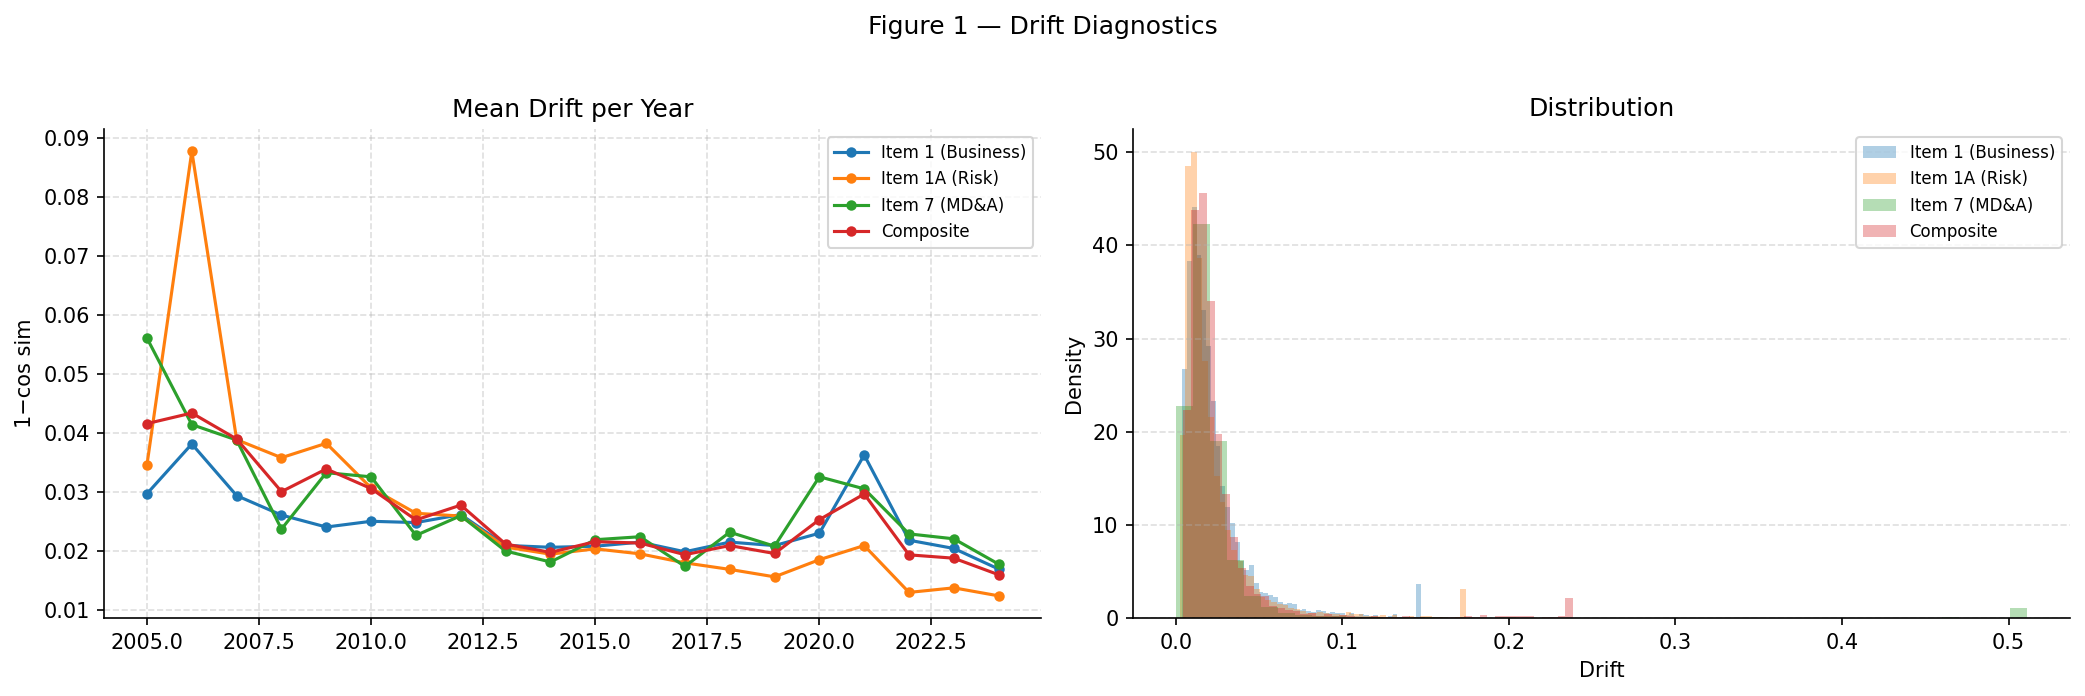

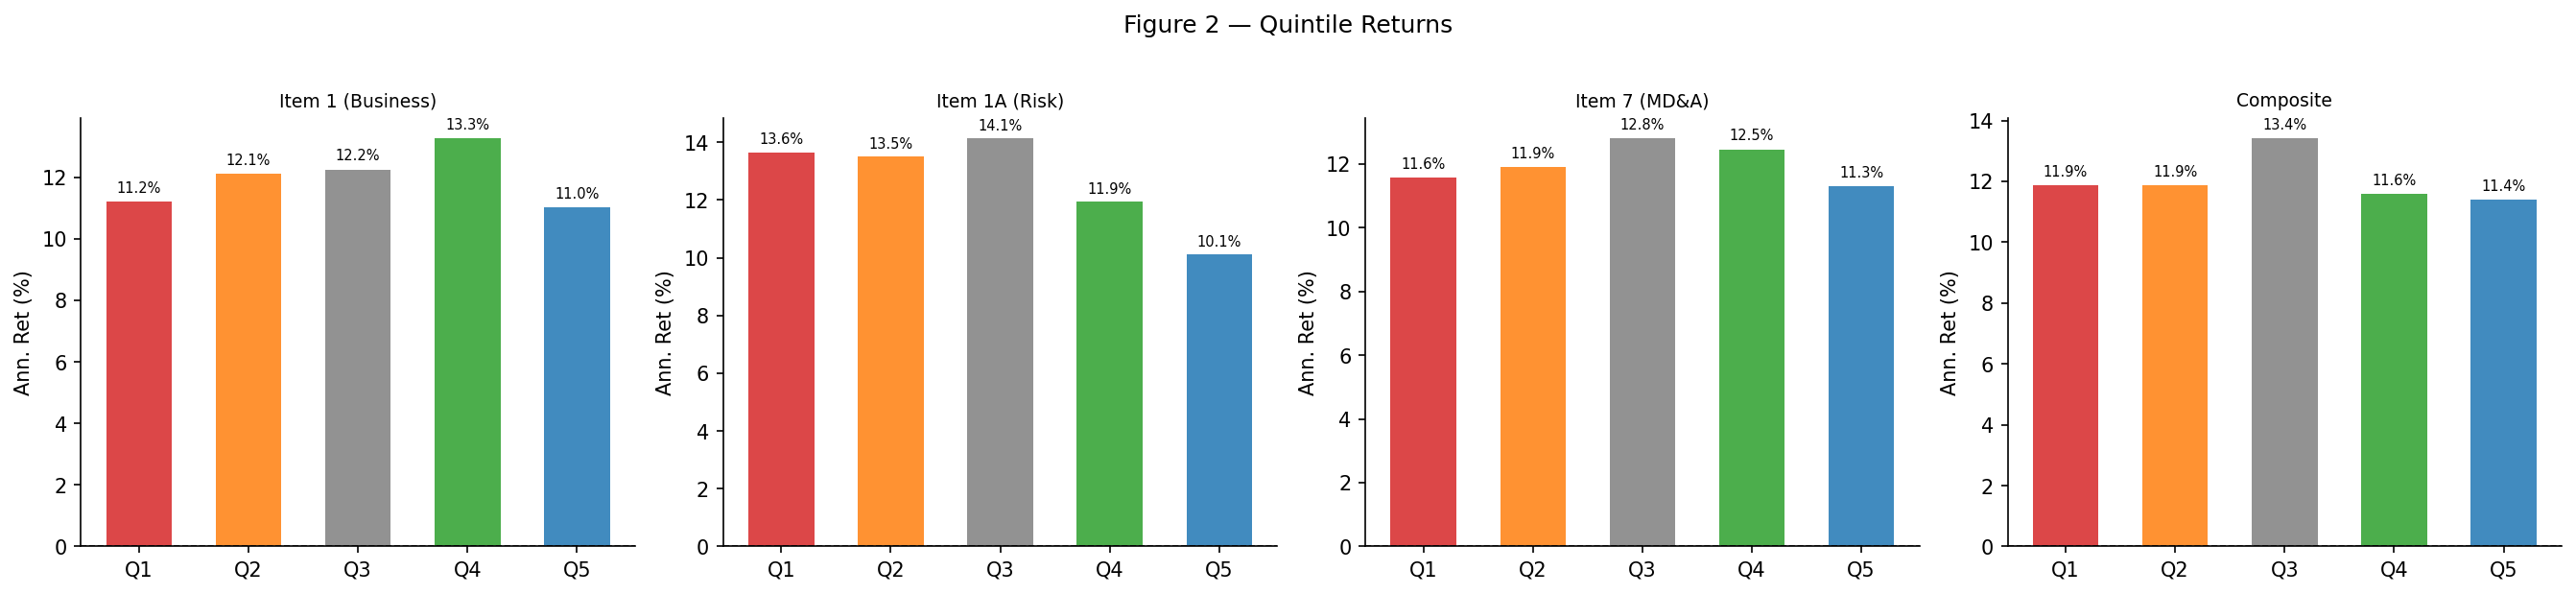

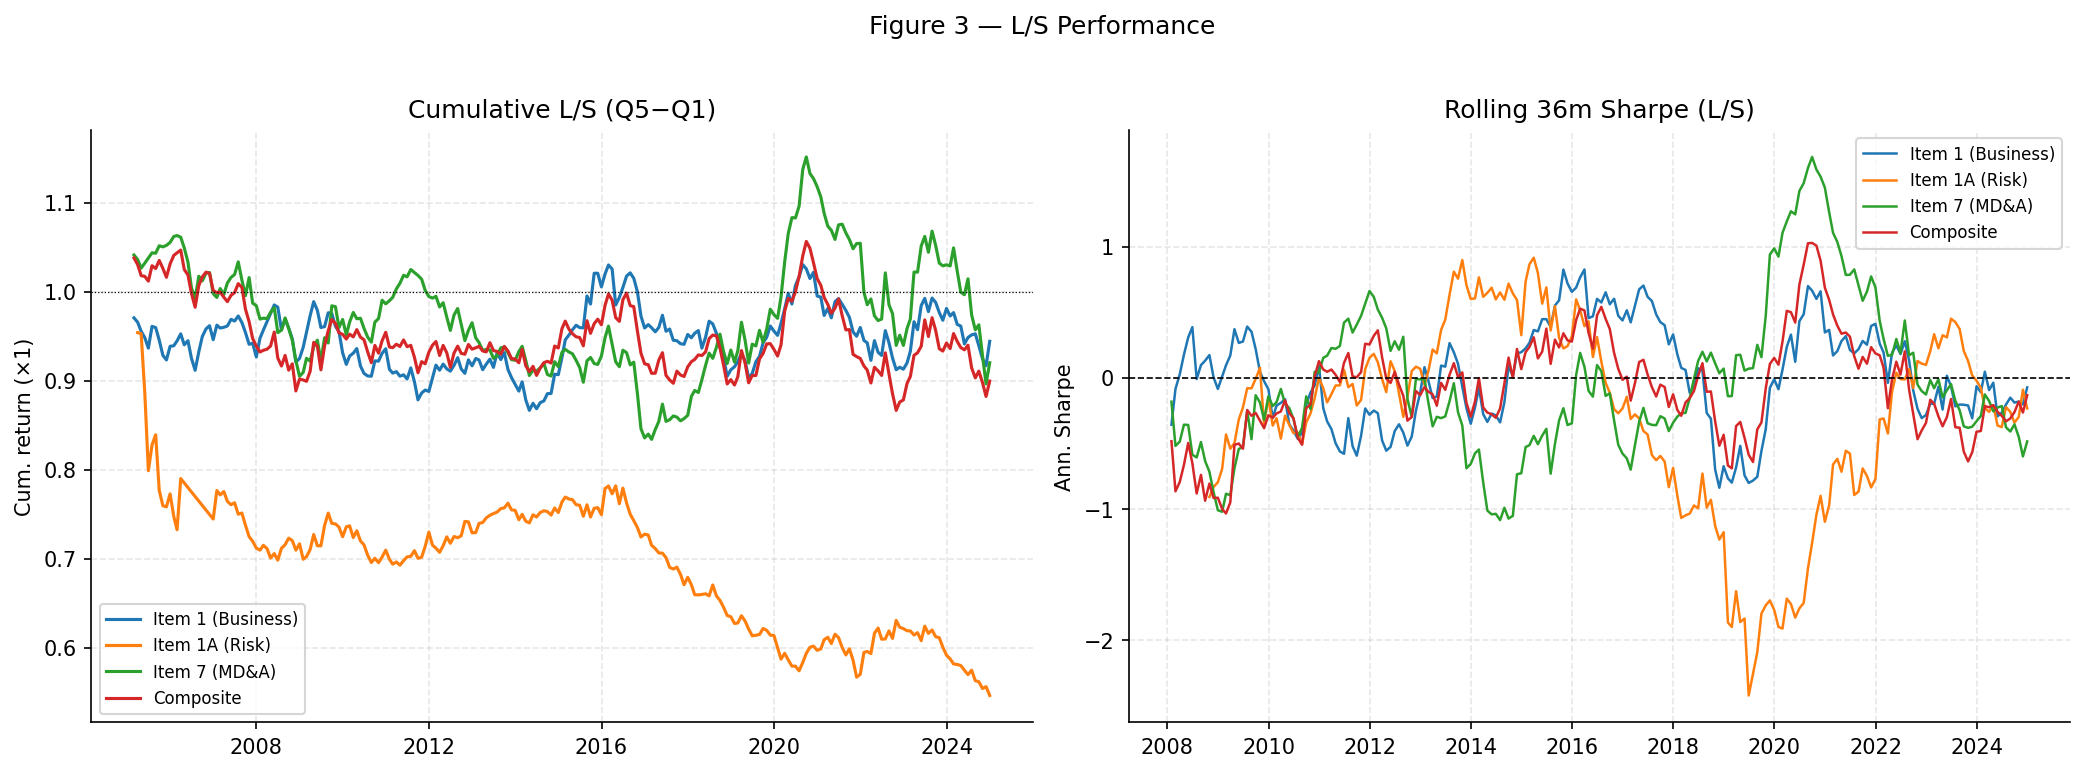

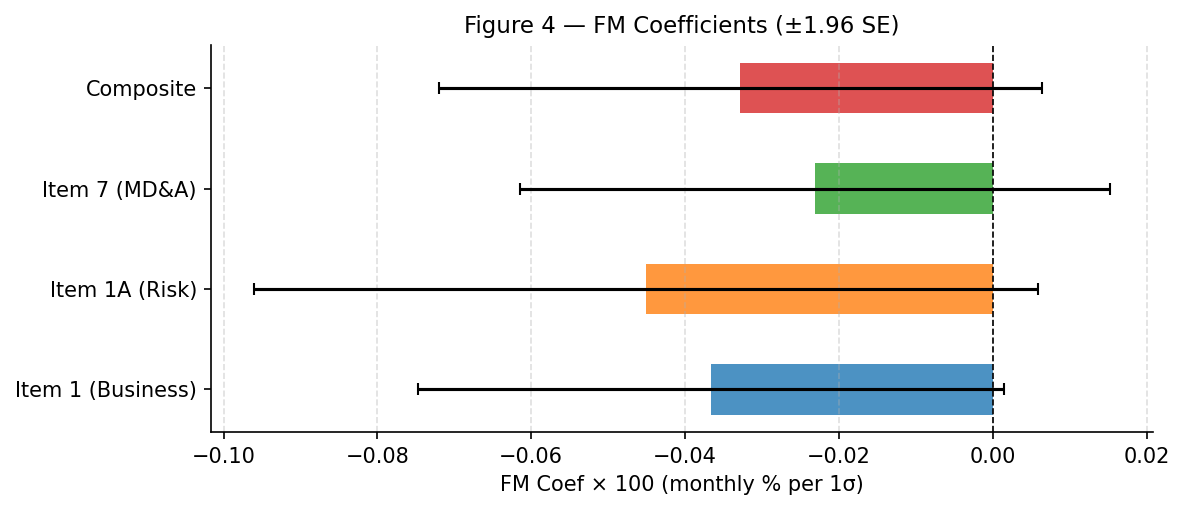

In [13]:
COLORS = {'drift_item_1':'#1f77b4','drift_item_1A':'#ff7f0e',
          'drift_item_7':'#2ca02c','drift_composite':'#d62728'}

# ── Fig 1: Drift diagnostics ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
for dc in all_drift_cols:
    if dc not in panel.columns: continue
    ann = panel.dropna(subset=[dc]).groupby('year')[dc].mean()
    ax.plot(ann.index, ann.values, marker='o', markersize=4,
            color=COLORS.get(dc,'gray'), linewidth=1.5,
            label=SIGNAL_LABELS.get(dc.replace('drift_',''),dc))
ax.set_title('Mean Drift per Year'); ax.set_ylabel('1−cos sim')
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)
ax = axes[1]
for dc in all_drift_cols:
    if dc not in panel.columns: continue
    ax.hist(panel[dc].dropna(), bins=50, alpha=0.35, color=COLORS.get(dc,'gray'),
            label=SIGNAL_LABELS.get(dc.replace('drift_',''),dc), density=True)
ax.set_title('Distribution'); ax.set_xlabel('Drift'); ax.set_ylabel('Density')
ax.legend(fontsize=8); ax.grid(axis='y', ls='--', alpha=0.4)
plt.suptitle('Figure 1 — Drift Diagnostics', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_folder'],'fig1_drift.pdf'), bbox_inches='tight')
plt.show()

# ── Fig 2: Quintile bars ──────────────────────────────────────────
n = len(sort_results)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(4.5*n, 4), squeeze=False)
    bc = ['#d62728','#ff7f0e','#7f7f7f','#2ca02c','#1f77b4']
    for ax, (dc, sr) in zip(axes.flat, sort_results.items()):
        qi = sr['q_info']
        qs = sorted(q for q in qi if isinstance(q, int))
        ar = [qi[q]['ann']*100 for q in qs]
        bars = ax.bar(qs, ar, color=bc[:len(qs)], alpha=0.85, width=0.6)
        ax.axhline(0, color='k', lw=0.8, ls='--')
        for b,v in zip(bars,ar):
            ax.text(b.get_x()+b.get_width()/2, v+np.sign(v)*0.3,
                    f'{v:.1f}%', ha='center', fontsize=7)
        ax.set_xticks(qs); ax.set_xticklabels([f'Q{q}' for q in qs])
        ax.set_title(SIGNAL_LABELS.get(dc.replace('drift_',''),dc), fontsize=9)
        ax.set_ylabel('Ann. Ret (%)')
    plt.suptitle('Figure 2 — Quintile Returns', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_folder'],'fig2_quintiles.pdf'), bbox_inches='tight')
    plt.show()

# ── Fig 3: Cumulative L/S + Rolling Sharpe ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for dc in all_drift_cols:
    if dc not in sort_results or 'LS' not in sort_results[dc]['q_info']: continue
    cum = (1+sort_results[dc]['q_info']['LS']['ts']).cumprod()
    ax.plot(cum.index, cum.values, lw=1.5, color=COLORS.get(dc,'gray'),
            label=SIGNAL_LABELS.get(dc.replace('drift_',''),dc))
ax.axhline(1, color='k', lw=0.6, ls=':')
ax.set_title('Cumulative L/S (Q5−Q1)'); ax.set_ylabel('Cum. return (×1)')
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.3)
ax = axes[1]
for dc in all_drift_cols:
    if dc not in sort_results or 'LS' not in sort_results[dc]['q_info']: continue
    ls_r = sort_results[dc]['q_info']['LS']['ts']
    rs = ls_r.rolling(36).mean()/ls_r.rolling(36).std()*np.sqrt(12)
    ax.plot(rs.index, rs.values, lw=1.2, color=COLORS.get(dc,'gray'),
            label=SIGNAL_LABELS.get(dc.replace('drift_',''),dc))
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('Rolling 36m Sharpe (L/S)'); ax.set_ylabel('Ann. Sharpe')
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.3)
plt.suptitle('Figure 3 — L/S Performance', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_folder'],'fig3_ls.pdf'), bbox_inches='tight')
plt.show()

# ── Fig 4: FM coefficients ────────────────────────────────────────
labs,coefs,errs,cols = [],[],[],[]
for dc in all_drift_cols:
    if dc not in fm_results: continue
    fm = fm_results[dc]['ctrl']
    if fm is None: continue
    sc = fm_results[dc]['std_col']
    row = fm[fm['Variable']==sc]
    if len(row)==0: continue
    r=row.iloc[0]
    labs.append(SIGNAL_LABELS.get(dc.replace('drift_',''),dc))
    coefs.append(r['Coef']*100)
    se = abs(r['Coef']*100/r['t_stat']) if abs(r['t_stat'])>1e-6 else 0
    errs.append(1.96*se); cols.append(COLORS.get(dc,'gray'))
if coefs:
    fig, ax = plt.subplots(figsize=(8,3.5))
    ax.barh(range(len(labs)), coefs, xerr=errs, color=cols, alpha=0.8, height=0.5, capsize=3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs)
    ax.set_xlabel('FM Coef × 100 (monthly % per 1σ)')
    ax.set_title('Figure 4 — FM Coefficients (±1.96 SE)', fontsize=11)
    ax.grid(axis='x', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_folder'],'fig4_fm.pdf'), bbox_inches='tight')
    plt.show()

## 13. LaTeX export

In [14]:
if HAS_FACTORS and ls_series:
    lines = [r'\begin{table}[htbp]', r'\centering',
        r'\caption{Long/Short Alpha Under Multiple Factor Models}',
        r'\label{tab:multi_alpha}']
    sigs = [dc for dc in all_drift_cols if dc in ls_series]
    lines.append(r'\begin{tabular}{l' + 'r'*len(sigs) + '}')
    lines.append(r'\toprule')
    lines.append('Model & ' + ' & '.join(
        SIGNAL_LABELS.get(dc.replace('drift_',''),dc) for dc in sigs) + r' \\')
    lines.append(r'\midrule')
    for mn, fc in FACTOR_SETS.items():
        cl, tl = mn, ''
        for dc in sigs:
            r = factor_reg(ls_series[dc], fc)
            if r is None: cl += ' & '; tl += ' & '
            else:
                cl += f' & {r["alpha_m"]*100:.4f}{stars(r["p_alpha"])}'
                tl += f' & [{r["t_alpha"]:.2f}]'
        lines.append(cl + r' \\'); lines.append(tl + r' \\')
    lines += [r'\bottomrule', r'\end{tabular}',
        r'\begin{tablenotes}', r'\small',
        r'\item Monthly $\alpha \times 100$. HAC NW (6 lags). *** $p<0.01$, ** $p<0.05$, * $p<0.10$.',
        r'\end{tablenotes}', r'\end{table}']
    tex = '\n'.join(lines)
    path = os.path.join(CONFIG['output_folder'], 'table4_multi_alpha.tex')
    with open(path, 'w') as f: f.write(tex)
    print(f'Saved: {path}'); print(tex)
else:
    print('Skipped.')

Saved: /content/drive/MyDrive/FML_project_4/table4_multi_alpha.tex
\begin{table}[htbp]
\centering
\caption{Long/Short Alpha Under Multiple Factor Models}
\label{tab:multi_alpha}
\begin{tabular}{lrrrr}
\toprule
Model & Item 1 (Business) & Item 1A (Risk) & Item 7 (MD&A) & Composite \\
\midrule
FF3 & -0.1932** & -0.3275** & -0.2458*** & -0.2179** \\
 & [-2.31] & [-2.43] & [-2.58] & [-2.56] \\
Carhart & -0.1737** & -0.3179** & -0.2286** & -0.1990** \\
 & [-2.02] & [-2.45] & [-2.41] & [-2.35] \\
FF5 & -0.2250*** & -0.3682*** & -0.2825*** & -0.2525*** \\
 & [-2.69] & [-2.92] & [-2.91] & [-3.03] \\
FF6 & -0.2069** & -0.3551*** & -0.2673*** & -0.2341*** \\
 & [-2.45] & [-2.94] & [-2.78] & [-2.82] \\
\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item Monthly $\alpha \times 100$. HAC NW (6 lags). *** $p<0.01$, ** $p<0.05$, * $p<0.10$.
\end{tablenotes}
\end{table}


## 15. Robustness: Varying holding-period horizons

The baseline uses a 12-month forward window. Here we test whether the
predictive power of each signal varies with the horizon by constructing
**1-month, 3-month, 6-month, and 12-month** forward return windows.

For each horizon $h$, we restrict the panel to months within $h$ months
of the filing date, then re-run:
1. Quintile L/S spreads
2. Fama-MacBeth regressions (standardised signal + controls)
3. Carhart 4-factor alpha on the L/S portfolio

This tells us **how quickly** the market incorporates each type of disclosure change.

In [15]:
# ── Build sub-panels for each horizon ─────────────────────────────
# The full panel already has return_month and filing_date.
# We compute months_after = months between filing_date and return_month,
# then filter for each horizon.

panel['months_after'] = (
    (panel['return_month'].dt.to_period('M').astype(int)) -
    (panel['filing_date'].dt.to_period('M').astype(int))
)

HORIZONS = [1, 3, 6, 12]

print(f'Months-after distribution:')
print(panel['months_after'].describe().round(1))
print(f'\nObs per horizon ceiling:')
for h in HORIZONS:
    n = (panel['months_after'] <= h).sum()
    print(f'  h={h:>2}m: {n:>10,} obs')

Months-after distribution:
count   112240.0000
mean         6.0000
std          3.7000
min          0.0000
25%          3.0000
50%          6.0000
75%          9.0000
max         12.0000
Name: months_after, dtype: float64

Obs per horizon ceiling:
  h= 1m:     17,082 obs
  h= 3m:     34,738 obs
  h= 6m:     61,013 obs
  h=12m:    112,240 obs


In [16]:
# ── Run analysis for each horizon × each signal ───────────────────

horizon_results = []  # list of dicts for final table

print('\nTable 6 — Return Predictability by Holding-Period Horizon')
print('='*100)
print(f'{"Signal":<22} {"Horizon":>8} {"LS Spread%":>12} {"LS t":>8} '
      f'{"FM β(std)":>12} {"FM t":>8} {"α(Carhart)":>12} {"α t":>8}')
print('-'*100)

for dc in all_drift_cols:
    std_col = f'{dc}_std'
    q_col   = f'{dc}_q'
    if std_col not in panel.columns or q_col not in panel.columns:
        continue
    label = SIGNAL_LABELS.get(dc.replace('drift_',''), dc)

    for h in HORIZONS:
        # Filter to horizon
        sub = panel[(panel['months_after'] >= 1) & (panel['months_after'] <= h)].copy()
        if len(sub) < 500:
            continue

        # ── 1. Quintile L/S spread ────────────────────────────────
        mq = (sub.dropna(subset=[q_col, 'monthly_return'])
                 .groupby(['return_month', q_col])['monthly_return']
                 .mean().unstack(q_col))
        ls_ret = np.nan
        ls_t   = np.nan
        if 5 in mq.columns and 1 in mq.columns:
            ls = (mq[5] - mq[1]).dropna()
            if len(ls) > 5:
                ls_ret = ls.mean()
                ls_t   = tstat_series(ls)

        # ── 2. Fama-MacBeth with controls ─────────────────────────
        fm_coef = np.nan
        fm_t    = np.nan
        fm = fama_macbeth(sub.dropna(subset=CONTROLS), 'monthly_return',
                          std_col, CONTROLS, 'return_month',
                          CONFIG['nw_lags'], CONFIG['min_xsec'])
        if fm is not None:
            row = fm[fm['Variable'] == std_col]
            if len(row) > 0:
                fm_coef = row.iloc[0]['Coef']
                fm_t    = row.iloc[0]['t_stat']

        # ── 3. Carhart alpha ──────────────────────────────────────
        alpha_m = np.nan
        alpha_t = np.nan
        if HAS_FACTORS and 5 in mq.columns and 1 in mq.columns:
            ls_ts = (mq[5] - mq[1]).dropna()
            ls_ts.index = pd.to_datetime(ls_ts.index).to_period('M').to_timestamp('M')
            ls_aligned = ls_ts.reindex(factors.index).dropna()
            if len(ls_aligned) >= 12:
                ls_exc = ls_aligned - factors.loc[ls_aligned.index, 'RF']
                y = ls_exc.values
                X = sm.add_constant(
                    factors.loc[ls_exc.index, ['MKT','SMB','HML','UMD']].values
                )
                try:
                    res = sm.OLS(y, X).fit(cov_type='HAC',
                                           cov_kwds={'maxlags': CONFIG['nw_lags']})
                    alpha_m = res.params[0]
                    alpha_t = res.tvalues[0]
                except:
                    pass

        # ── Store and print ───────────────────────────────────────
        horizon_results.append({
            'signal': dc, 'label': label, 'horizon': h,
            'ls_ret': ls_ret, 'ls_t': ls_t,
            'fm_coef': fm_coef, 'fm_t': fm_t,
            'alpha': alpha_m, 'alpha_t': alpha_t,
        })

        ls_st = stars(2*stats.t.sf(abs(ls_t), 100)) if not np.isnan(ls_t) else ''
        fm_st = stars(2*stats.t.sf(abs(fm_t), 100)) if not np.isnan(fm_t) else ''
        al_st = stars(2*stats.t.sf(abs(alpha_t), 100)) if not np.isnan(alpha_t) else ''

        print(f'{label:<22} {h:>6}m  '
              f'{ls_ret*100 if not np.isnan(ls_ret) else 0:>10.4f}{ls_st:>2s}  '
              f'{ls_t if not np.isnan(ls_t) else 0:>7.2f}  '
              f'{fm_coef*100 if not np.isnan(fm_coef) else 0:>10.4f}{fm_st:>2s}  '
              f'{fm_t if not np.isnan(fm_t) else 0:>7.2f}  '
              f'{alpha_m*100 if not np.isnan(alpha_m) else 0:>10.4f}{al_st:>2s}  '
              f'{alpha_t if not np.isnan(alpha_t) else 0:>7.2f}')

    print()  # blank line between signals

print('='*100)
print('LS Spread and Alpha × 100 (monthly %). FM β is per 1σ of signal × 100.')


Table 6 — Return Predictability by Holding-Period Horizon
Signal                  Horizon   LS Spread%     LS t    FM β(std)     FM t   α(Carhart)      α t
----------------------------------------------------------------------------------------------------
Item 1 (Business)           1m      0.5832       1.12     -0.0457      -0.29      0.8091 *     1.77
Item 1 (Business)           3m      0.0157       0.07     -0.1195      -1.22     -0.0064      -0.03
Item 1 (Business)           6m      0.1783       1.02     -0.0326      -0.59      0.1044       0.51
Item 1 (Business)          12m     -0.0155      -0.17     -0.0342 *    -1.73     -0.1838**    -2.14

Item 1A (Risk)              1m     -0.3313      -0.72     -0.0041      -0.02     -0.2558      -0.61
Item 1A (Risk)              3m     -0.2273      -0.77      0.0228       0.19     -0.2440      -0.88
Item 1A (Risk)              6m     -0.1545      -0.79     -0.1232 *    -1.85     -0.2110      -0.95
Item 1A (Risk)             12m     -0.188

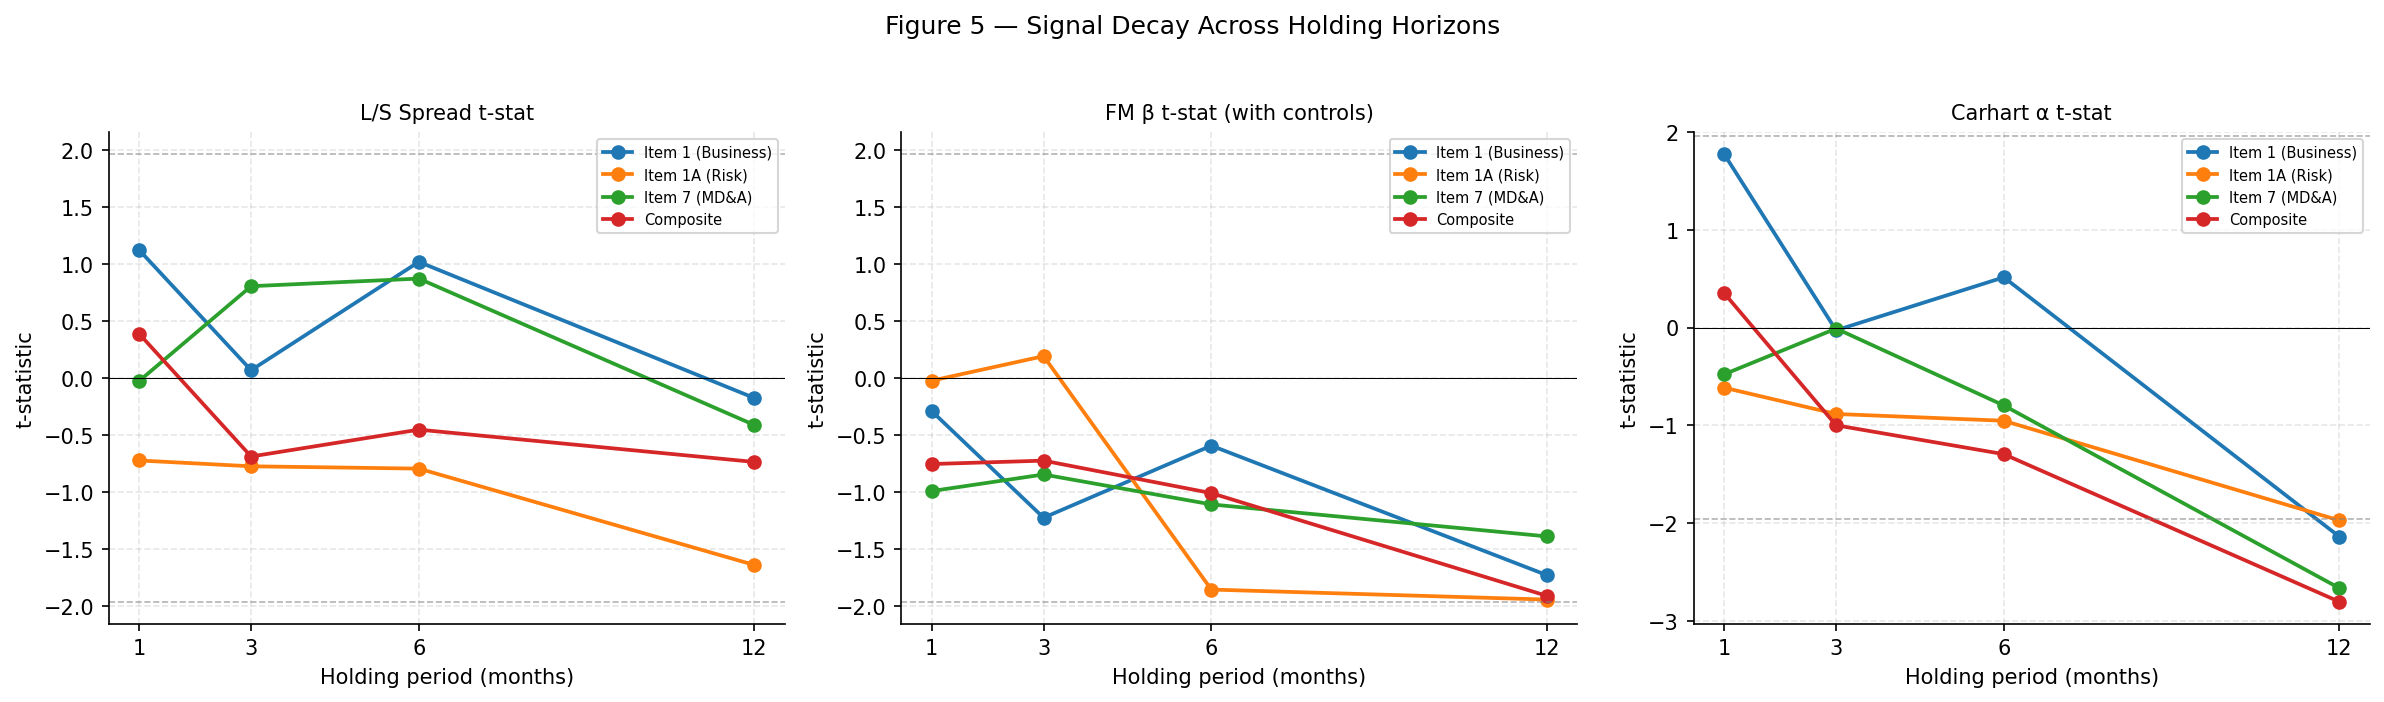

Interpretation: signals crossing the ±1.96 dashed line are significant at 5%.


In [17]:
# ── Figure 5: Horizon decay plot ─────────────────────────────────
hr_df = pd.DataFrame(horizon_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

COLORS = {'drift_item_1':'#1f77b4', 'drift_item_1A':'#ff7f0e',
          'drift_item_7':'#2ca02c', 'drift_composite':'#d62728'}

for ax, (metric, ylabel, title) in zip(axes, [
    ('ls_t',    't-statistic',       'L/S Spread t-stat'),
    ('fm_t',    't-statistic',       'FM β t-stat (with controls)'),
    ('alpha_t', 't-statistic',       'Carhart α t-stat'),
]):
    for dc in all_drift_cols:
        sub = hr_df[hr_df['signal'] == dc]
        if len(sub) == 0: continue
        label = SIGNAL_LABELS.get(dc.replace('drift_',''), dc)
        ax.plot(sub['horizon'], sub[metric], marker='o', markersize=6,
                color=COLORS.get(dc, 'gray'), linewidth=1.8, label=label)
    ax.axhline(-1.96, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline( 1.96, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Holding period (months)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(HORIZONS)
    ax.legend(fontsize=7)
    ax.grid(linestyle='--', alpha=0.3)

plt.suptitle('Figure 5 — Signal Decay Across Holding Horizons', fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_folder'], 'fig5_horizon_decay.pdf'),
            bbox_inches='tight')
plt.show()
print('Interpretation: signals crossing the ±1.96 dashed line are significant at 5%.')

## 16. Interaction analysis: drift × firm characteristics

The limited-attention hypothesis predicts that the drift effect is stronger for:
- **Smaller firms** (less analyst coverage → slower information incorporation)
- **Low book-to-market firms** (growth firms → more uncertainty about future)
- **Low profitability firms** (strategic shifts driven by distress → more informative)

We test this by adding interaction terms: `drift_std × characteristic`
in Fama-MacBeth regressions, and by running conditional double-sorts.

### 16a. Fama-MacBeth with interactions

In [18]:
# ── Create interaction terms ──────────────────────────────────────
# Standardise characteristics cross-sectionally first
for char in ['log_mktcap', 'bm', 'profitability']:
    if char in panel.columns:
        panel[f'{char}_std'] = (
            panel.groupby('return_month')[char]
                 .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
        )

INTERACTIONS = [
    ('log_mktcap_std', 'Size',          'Small firms should show stronger effect'),
    ('bm_std',         'Book/Market',    'Growth firms should show stronger effect'),
    ('profitability',  'ROA',            'Low-profit firms should show stronger effect'),
]

print('\nTable 7 — Fama-MacBeth with Interaction Terms')
print('Signal × Characteristic interactions. NW SE (6 lags). Coefs × 100.')
print('='*95)
print(f'{"Signal":<22} {"Interacted with":<16} {"β(drift)":>10} {"t":>7}  '
      f'{"β(interact)":>12} {"t":>7}  {"T":>5} {"N":>5}')
print('-'*95)

interaction_results = []

for dc in all_drift_cols:
    std_col = f'{dc}_std'
    if std_col not in panel.columns:
        continue
    label = SIGNAL_LABELS.get(dc.replace('drift_',''), dc)

    for char_col, char_label, hypothesis in INTERACTIONS:
        if char_col not in panel.columns:
            continue

        # Create interaction column
        inter_col = f'{dc}_x_{char_col}'
        panel[inter_col] = panel[std_col] * panel[char_col]

        # FM regression: drift_std + characteristic + interaction + other controls
        other_ctrls = [c for c in CONTROLS if c != char_col.replace('_std','')]
        fm_vars = [char_col, inter_col] + other_ctrls

        fm = fama_macbeth(
            panel.dropna(subset=[std_col] + fm_vars + ['monthly_return']),
            'monthly_return', std_col, fm_vars,
            'return_month', CONFIG['nw_lags'], CONFIG['min_xsec']
        )

        if fm is not None:
            # Extract drift coefficient
            r_drift = fm[fm['Variable'] == std_col]
            # Extract interaction coefficient
            r_inter = fm[fm['Variable'] == inter_col]

            if len(r_drift) > 0 and len(r_inter) > 0:
                d = r_drift.iloc[0]
                ix = r_inter.iloc[0]
                T_months = int(fm['N_months'].iloc[0])
                avg_n = int(fm['Avg_N'].iloc[0])

                interaction_results.append({
                    'signal': dc, 'label': label,
                    'char': char_label,
                    'drift_coef': d['Coef'], 'drift_t': d['t_stat'],
                    'inter_coef': ix['Coef'], 'inter_t': ix['t_stat'],
                    'T': T_months, 'N': avg_n,
                })

                print(f'{label:<22} {char_label:<16} '
                      f'{d["Coef"]*100:>9.4f}{stars(d["p_val"])}  '
                      f'({d["t_stat"]:>5.2f})  '
                      f'{ix["Coef"]*100:>10.4f}{stars(ix["p_val"])}  '
                      f'({ix["t_stat"]:>5.2f})  '
                      f'{T_months:>5} {avg_n:>5}')

        # Clean up
        panel.drop(columns=[inter_col], inplace=True, errors='ignore')

    print()  # blank line between signals

print('='*95)
print('β(interact) < 0 with Size means drift effect stronger for small firms.')
print('β(interact) > 0 with B/M means drift effect stronger for value firms.')


Table 7 — Fama-MacBeth with Interaction Terms
Signal × Characteristic interactions. NW SE (6 lags). Coefs × 100.
Signal                 Interacted with    β(drift)       t   β(interact)       t      T     N
-----------------------------------------------------------------------------------------------
Item 1 (Business)      Size               -0.0454**  (-2.14)      0.0593**  ( 2.32)    239   449
Item 1 (Business)      Book/Market        -0.0415**  (-2.08)     -0.0889***  (-3.32)    239   449
Item 1 (Business)      ROA                -0.0873**  (-2.56)      0.7280*  ( 1.89)    239   449

Item 1A (Risk)         Size               -0.0447*  (-1.69)      0.0044  ( 0.16)    215   447
Item 1A (Risk)         Book/Market        -0.0414  (-1.51)     -0.0534**  (-2.06)    215   447
Item 1A (Risk)         ROA                -0.0653  (-1.51)      0.4427  ( 0.75)    215   447

Item 7 (MD&A)          Size               -0.0229  (-0.67)      0.0659*  ( 1.86)    239   450
Item 7 (MD&A)          Book

### 16b. Conditional double-sorts

Sort firms independently into terciles by size, then within each size tercile,
sort into quintiles by drift. This non-parametrically tests whether the drift
effect is concentrated in small vs large firms.

In [19]:
# ── Double sort: Size tercile × Drift quintile ────────────────────

# Focus on Item 1A (strongest signal)
FOCUS_SIGNAL = 'drift_item_1A'
focus_label  = 'Item 1A (Risk Factors)'

if FOCUS_SIGNAL in panel.columns and 'log_mktcap' in panel.columns:
    sub = panel.dropna(subset=[FOCUS_SIGNAL, 'log_mktcap', 'monthly_return']).copy()

    # Terciles by size within each year
    sub['size_tercile'] = (
        sub.groupby('year')['log_mktcap']
           .transform(lambda x: pd.qcut(x.rank(method='first'), 3,
                                        labels=['Small', 'Mid', 'Large']))
    )

    # Quintiles by drift WITHIN each size tercile × year
    sub['drift_q_cond'] = (
        sub.groupby(['year', 'size_tercile'])[FOCUS_SIGNAL]
           .transform(lambda x: pd.qcut(x.rank(method='first'), 5,
                                        labels=[1,2,3,4,5]) if len(x) >= 10 else np.nan)
    )
    sub['drift_q_cond'] = pd.to_numeric(sub['drift_q_cond'], errors='coerce')

    print(f'\nTable 8 — Double Sort: Size Tercile × {focus_label} Quintile')
    print('Equal-weighted monthly returns (%)')
    print('='*75)
    print(f'{"Size \\ Drift":<12}', '  '.join(f'{"Q"+str(q):>10}' for q in [1,2,3,4,5]),
          f'{"Q5-Q1":>10}', f'{"t":>8}')
    print('-'*75)

    ds_results = []
    for sz in ['Small', 'Mid', 'Large']:
        sz_sub = sub[sub['size_tercile'] == sz]
        mq = (sz_sub.dropna(subset=['drift_q_cond'])
                     .groupby(['return_month', 'drift_q_cond'])['monthly_return']
                     .mean().unstack('drift_q_cond'))

        q_means = []
        for q in [1,2,3,4,5]:
            if q in mq.columns:
                q_means.append(mq[q].mean() * 100)
            else:
                q_means.append(np.nan)

        ls_spread = np.nan
        ls_t_val  = np.nan
        if 5 in mq.columns and 1 in mq.columns:
            ls = (mq[5] - mq[1]).dropna()
            ls_spread = ls.mean() * 100
            ls_t_val  = tstat_series(ls)

        ds_results.append({'size': sz, 'q_means': q_means,
                           'spread': ls_spread, 't': ls_t_val})

        q_str = '  '.join(f'{v:>10.3f}' if not np.isnan(v) else f'{"":>10}'
                          for v in q_means)
        sp_str = f'{ls_spread:>10.3f}' if not np.isnan(ls_spread) else f'{"":>10}'
        t_str  = f'({ls_t_val:>5.2f}){stars(2*stats.t.sf(abs(ls_t_val),100)) if not np.isnan(ls_t_val) else ""}' if not np.isnan(ls_t_val) else ''
        print(f'{sz:<12} {q_str}  {sp_str} {t_str:>8}')

    print('='*75)
    print('Drift quintiles formed within each size tercile (conditional sort).')
    print('A larger |Q5-Q1| in Small vs Large supports the limited-attention hypothesis.')
else:
    print(f'{FOCUS_SIGNAL} or log_mktcap not available.')


Table 8 — Double Sort: Size Tercile × Item 1A (Risk Factors) Quintile
Equal-weighted monthly returns (%)
Size \ Drift         Q1          Q2          Q3          Q4          Q5      Q5-Q1        t
---------------------------------------------------------------------------
Small             0.144       0.303       0.264       0.454       0.233       0.019  ( 0.11)
Mid               1.171       1.319       1.237       1.402       1.125       0.036  ( 0.25)
Large             1.445       1.524       1.347       1.401       1.133      -0.250 (-1.67)*
Drift quintiles formed within each size tercile (conditional sort).
A larger |Q5-Q1| in Small vs Large supports the limited-attention hypothesis.


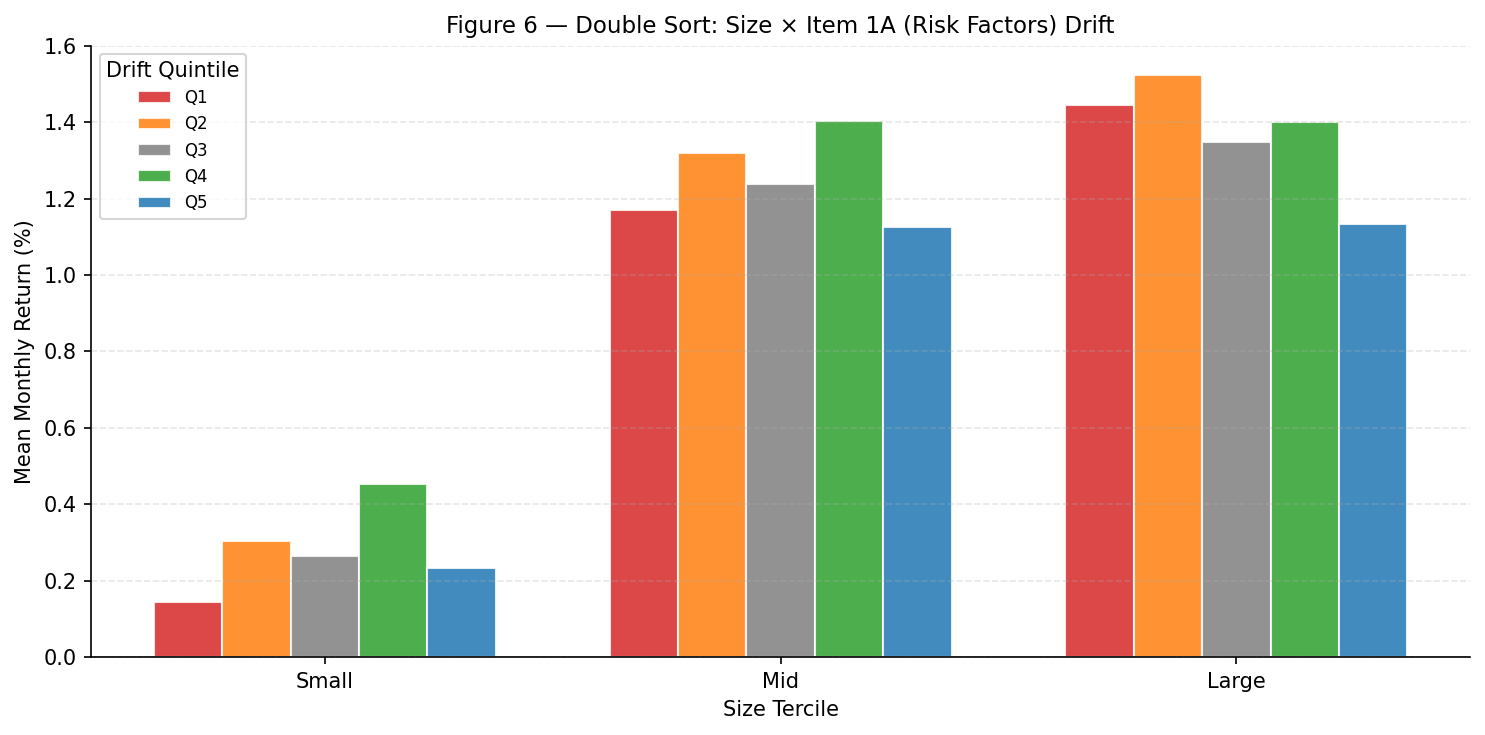

In [20]:
# ── Figure 6: Double-sort grouped bar chart ──────────────────────
if ds_results:
    fig, ax = plt.subplots(figsize=(10, 5))

    size_labels = [r['size'] for r in ds_results]
    x = np.arange(3)  # 3 size terciles
    width = 0.15
    q_colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1f77b4']

    for i, q in enumerate([1,2,3,4,5]):
        vals = [r['q_means'][i] for r in ds_results]
        ax.bar(x + (i-2)*width, vals, width, label=f'Q{q}',
               color=q_colors[i], alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(size_labels)
    ax.set_xlabel('Size Tercile')
    ax.set_ylabel('Mean Monthly Return (%)')
    ax.set_title(f'Figure 6 — Double Sort: Size × {focus_label} Drift', fontsize=11)
    ax.legend(title='Drift Quintile', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_folder'], 'fig6_double_sort.pdf'),
                bbox_inches='tight')
    plt.show()

## 14. Summary

In [21]:
print('='*70)
print('ANALYSIS COMPLETE')
print('='*70)
for dc in all_drift_cols:
    n = panel[dc].notna().sum()
    print(f'  {SIGNAL_LABELS.get(dc.replace("drift_",""),dc)}: {n:,} obs')
mc = panel.groupby('return_month')['cik'].nunique()
print(f'\nPanel: {len(panel):,} firm-months  |  {panel["cik"].nunique():,} CIKs')
print(f'Monthly cross-sections: {len(mc)} months, mean {mc.mean():.0f} firms/month')
print(f'Period: {panel["return_month"].min().date()} – {panel["return_month"].max().date()}')

ANALYSIS COMPLETE
  Item 1 (Business): 111,023 obs
  Item 1A (Risk): 99,825 obs
  Item 7 (MD&A): 111,259 obs
  Composite: 112,240 obs

Panel: 112,240 firm-months  |  811 CIKs
Monthly cross-sections: 240 months, mean 435 firms/month
Period: 2005-01-31 – 2024-12-31
